<a href="https://colab.research.google.com/github/dariaivanow/Visualisation-project/blob/main/GymMembersVisualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import altair as alt
import seaborn as sns
import scipy
import pywaffle

Этот датасет предоставляет детальную информацию о тренировках посетителей спортзала, их физических характеристиках и показателях физической формы.

Датасет содержит столбцы:
* Age: Возраст
* Gender: Пол
* Weight (kg): Вес (кг)
* Height (m): Рост (м)
* Max_BPM: Максимальный пульс
* Avg_BPM: Средний пульс
* Resting_BPM: Пульс во время отдыха между подходами
* Session_Duration (hours): Время тренировки (часов)
* Calories_Burned: Количество сожженных калорий
* Workout_Type: Вид тренировки (силовая, йога, кардио и пр.)
* Fat_Percentage: Процент жира человека
* Water_Intake (liters): Количество выпитой воды в день (л)
* Workout_Frequency (days/week): Количество тренировок в неделю
* Experience_Level: Опыт в спорте от новичка (1) до профи (3)
* BMI: Индекс массы тела




In [ ]:
df = pd.read_csv('gym_members_exercise_tracking.csv', sep=',')
df.sample(5)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
918,28,Female,72.9,1.67,197,147,74,1.13,831.0,Cardio,34.7,2.2,3,2,26.14
526,22,Male,98.4,1.88,194,135,71,0.52,386.0,Cardio,21.3,2.2,2,1,27.84
510,42,Male,63.7,1.98,172,128,69,1.37,868.0,Yoga,24.0,3.0,2,1,16.25
105,40,Female,56.2,1.79,198,153,57,1.79,1369.0,Yoga,17.6,2.7,5,3,17.54
712,19,Male,82.4,1.96,174,169,62,1.90,1766.0,HIIT,10.1,3.5,5,3,21.45


Распределение по полу

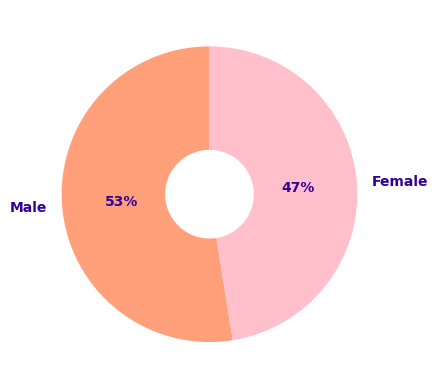

In [ ]:
import matplotlib.pyplot as plt

gender_counts = df['Gender'].value_counts()
colors = ['#FFA07A', '#FFC0CB']

fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.0f%%',
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.7)
)

plt.setp(autotexts, size=10, weight='bold', color='#330198')
plt.setp(texts, size=10, weight='bold', color = '#330198')

ax.set(aspect="equal")
plt.show()

Распределение по возрасту

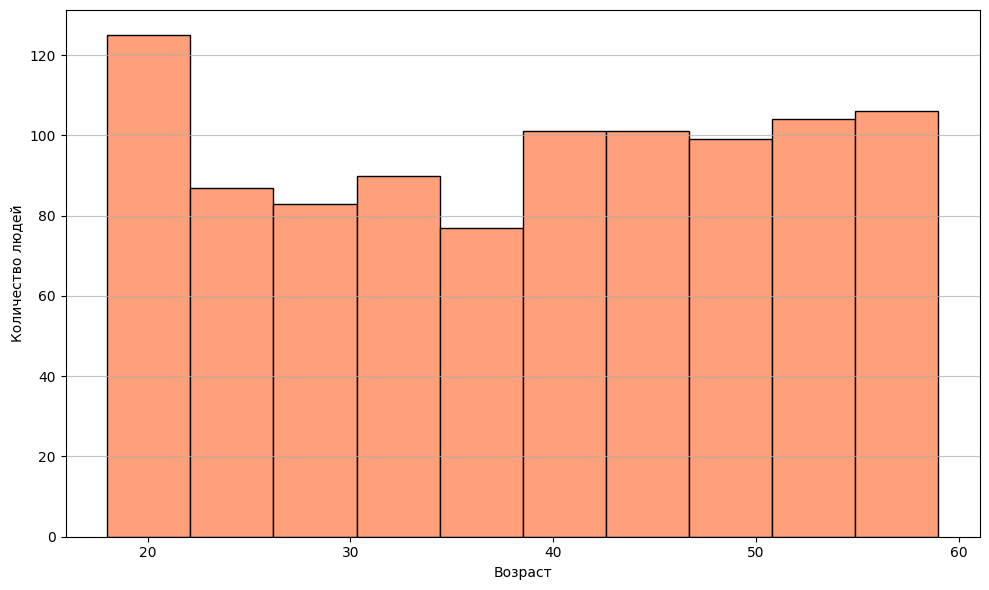

In [15]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=10, edgecolor='black', color='#FFA07A')
plt.xlabel('Возраст')
plt.ylabel('Количество людей')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Зависимость сожженных калорий от пульса и продолжительности занятий

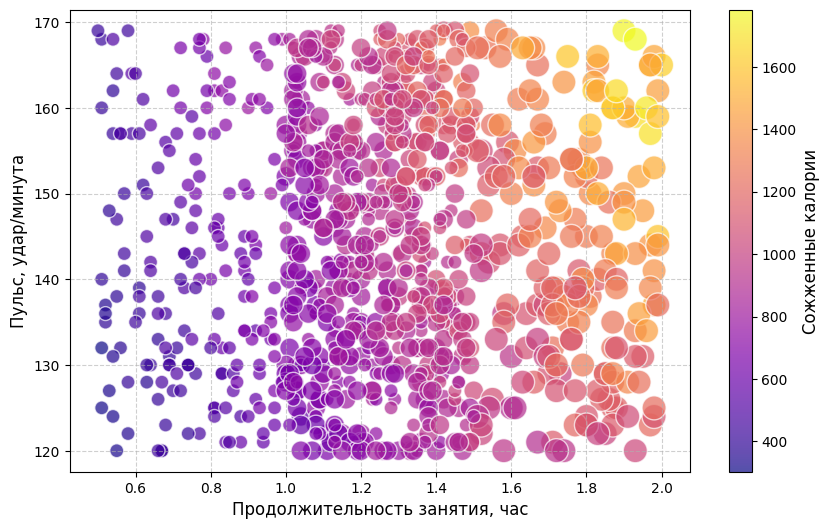

In [18]:
import pandas as pd
import matplotlib.pyplot as plt


x = df['Session_Duration (hours)']
y = df['Avg_BPM']
calories = df['Calories_Burned']
experience = df['Experience_Level']

bubble_size = experience * 100

plt.figure(figsize=(10, 6))
scatter = plt.scatter(x, y, s=bubble_size, c=calories, cmap='plasma', alpha=0.7, edgecolors='w')

cbar = plt.colorbar(scatter)
cbar.set_label('Сожженные калории', fontsize=12)

plt.xlabel('Продолжительность занятия, час', fontsize=12)
plt.ylabel('Пульс, удар/минута', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Влияние частоты тренировок на количество сожженных калорий

<ipython-input-20-7cfd20ba8789>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Workout_Frequency (days/week)', y='Calories_Burned', data=calories_per_frequency, palette='plasma')


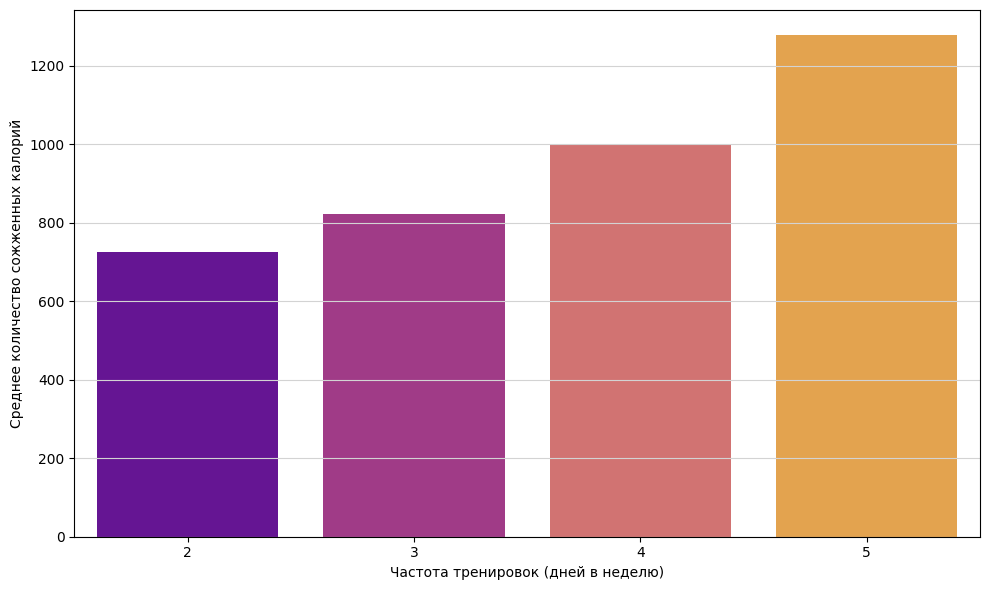

In [20]:
calories_per_frequency = df.groupby('Workout_Frequency (days/week)')['Calories_Burned'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Workout_Frequency (days/week)', y='Calories_Burned', data=calories_per_frequency, palette='plasma')

plt.xlabel('Частота тренировок (дней в неделю)')
plt.ylabel('Среднее количество сожженных калорий')
plt.xticks
plt.grid(axis = 'y', color = 'lightgrey')
plt.tight_layout()
plt.show()

Зависимость сожженых калорий от уровня опыта

<ipython-input-21-eea3d7e69119>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Experience_Level', y='Calories_Burned', data=df, palette='plasma')


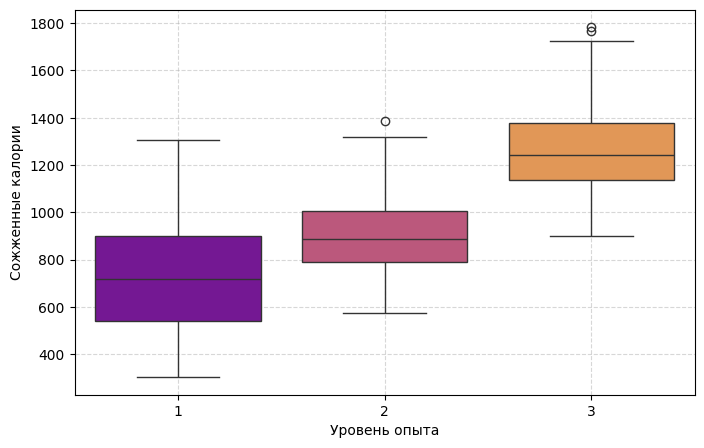

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Experience_Level', y='Calories_Burned', data=df, palette='plasma')

plt.xlabel("Уровень опыта")
plt.ylabel("Сожженные калории")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Корреляция всез признаков с количеством сожженных калорий

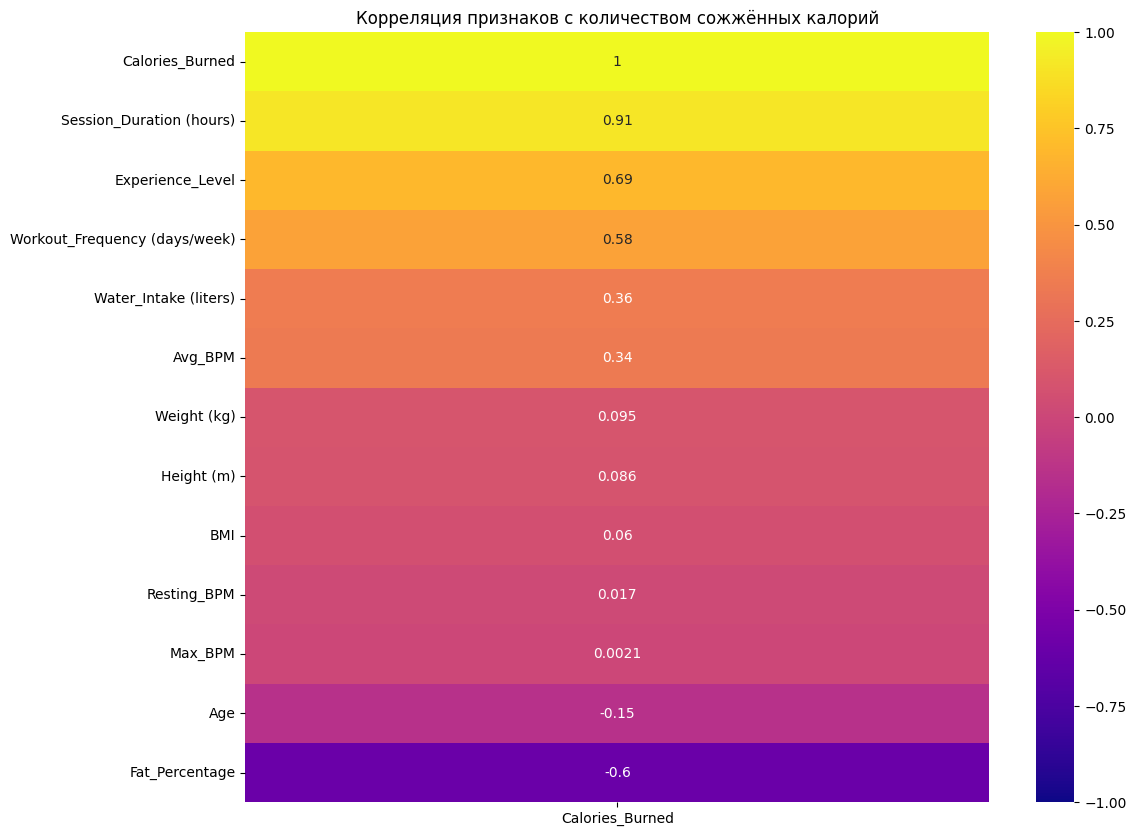

In [27]:
features = [
    'Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
    'Session_Duration (hours)', 'Fat_Percentage', 'Water_Intake (liters)',
    'Workout_Frequency (days/week)', 'Experience_Level', 'BMI'
]

corr_matrix = df[features + ['Calories_Burned']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix[['Calories_Burned']].sort_values(by='Calories_Burned', ascending=False),
            annot=True, cmap='plasma', vmin=-1, vmax=1)
plt.title('Корреляция признаков с количеством сожжённых калорий')
plt.show()

На полученном графике можно заметить, что наибольшее влияние на количество сожженных калорий оказывает продолжительность тренировки, с коэффициентом 0.91, а наименьшее - индекс массы тела и значения пульса. Также можно заметить достаточно сильную обратную зависимость с показателем процента жира - это означает, что чем он больше, тем больше калорий будет потеряно за тренировку.